# Portfolio Performance Metrics

While return and volatility provide useful information, professional portfolio evaluation requires additional risk-adjusted performance measures.

This notebook computes:

- Sharpe Ratio
- Sortino Ratio
- Maximum Drawdown
- Calmar Ratio


In [13]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('fivethirtyeight')

In [14]:
returns = pd.read_csv(
    '../data/optimized_returns.csv',
    index_col=0,
    parse_dates=True
).squeeze()

## Sharpe Ratio

The Sharpe Ratio measures excess return earned per unit of total risk.

Higher values indicate superior risk-adjusted performance.

In [15]:
risk_free_rate = 0.04

annual_return = returns.mean() * 252

annual_volatility = returns.std() * np.sqrt(252)

sharpe_ratio = (
    annual_return - risk_free_rate
) / annual_volatility

print(sharpe_ratio)

2.405024427458703


## Sortino Ratio

Unlike the Sharpe Ratio, the Sortino Ratio considers only downside volatility.

This provides a more investor-focused measure of risk-adjusted performance.

In [16]:
downside_returns = returns[returns < 0]

downside_std = (
    downside_returns.std()
    * np.sqrt(252)
)

sortino_ratio = (
    annual_return - risk_free_rate
) / downside_std

print(sortino_ratio)

3.979108610890756


## Maximum Drawdown

Maximum Drawdown represents the largest peak-to-trough decline experienced by the portfolio.

It measures downside risk and capital preservation.

In [17]:
cumulative_returns = (
    1 + returns
).cumprod()

running_max = cumulative_returns.cummax()

drawdown = (
    cumulative_returns
    - running_max
) / running_max

max_drawdown = drawdown.min()

print(max_drawdown)

-0.1496684421312983


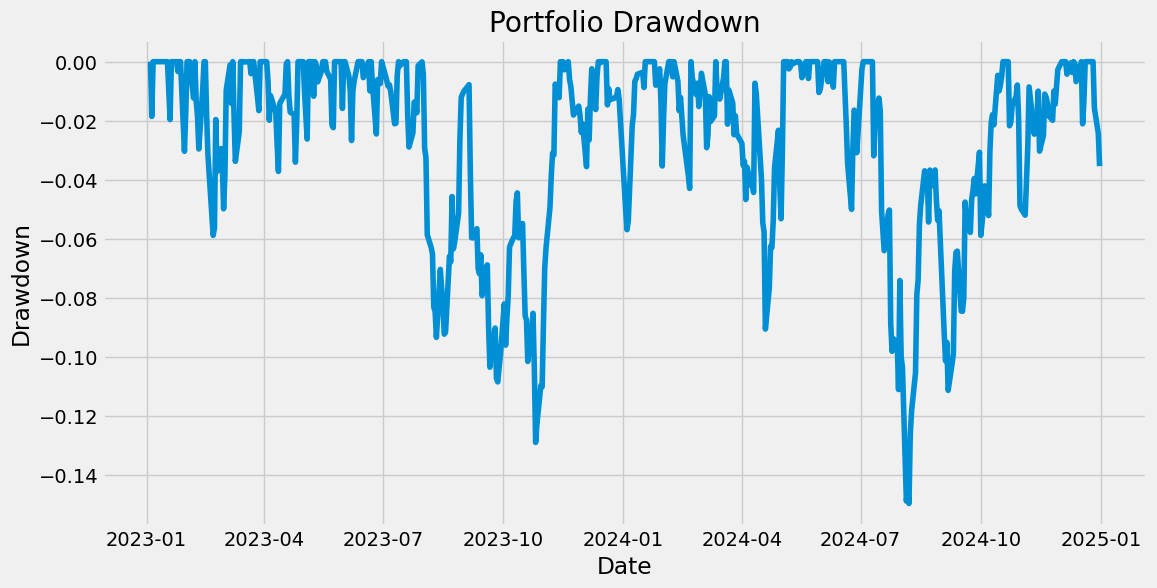

In [22]:
plt.figure(figsize=(12,6))

plt.plot(drawdown)

plt.title('Portfolio Drawdown')

plt.xlabel('Date')

plt.ylabel('Drawdown')

plt.savefig('../images/portfolio_drawdown.png', bbox_inches = 'tight')

plt.show()

## Calmar Ratio

The Calmar Ratio compares annualized return against maximum drawdown.

Higher values indicate better return generation relative to downside risk.

In [19]:
calmar_ratio = (
    annual_return
    / abs(max_drawdown)
)

print(calmar_ratio)

4.006721301545291


In [20]:
metrics = pd.DataFrame({
    'Metric': [
        'Annual Return',
        'Annual Volatility',
        'Sharpe Ratio',
        'Sortino Ratio',
        'Maximum Drawdown',
        'Calmar Ratio'
    ],
    'Value': [
        annual_return,
        annual_volatility,
        sharpe_ratio,
        sortino_ratio,
        max_drawdown,
        calmar_ratio
    ]
})

metrics

,Metric,Value
0,Annual Return,0.599680
1,Annual Volatility,0.232713
2,Sharpe Ratio,2.405024
3,Sortino Ratio,3.979109
4,Maximum Drawdown,-0.149668
5,Calmar Ratio,4.006721


In [21]:
metrics.to_csv(
    '../data/performance_metrics.csv',
    index=False
)